#Structural Targets Extraction

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

!pip -q install factor_analyzer
from factor_analyzer import FactorAnalyzer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
file_path = '/content/Copy of Just Capital_Business Views Max Diff Study_Final Weighted Data_withutilities_Confidential.09102025.xlsx'
df = pd.read_excel(file_path)
df

,RESPID,STATUS,INTERVIEW_START,INTERVIEW_END,XCHANNEL,RESPONDENTSTATUS,HID_LOI,DEVICETYPE,DEVICECATEGORY,PGENDER,...,Att12,Att13,Att14,Att15,Att16,Att17,urbanicity_bb,income_bb,invest_bb,large_bb
0,2.0,complete,2025-08-26,2025-08-26,1.0,13.0,1438.0,2.0,3.0,2.0,...,9.828460,14.913427,0.710278,0.269490,0.157819,0.337140,3.0,NaN,3.0,2.0
1,3.0,complete,2025-08-19,2025-08-19,1.0,13.0,822.0,1.0,1.0,2.0,...,1.243191,15.272396,0.074779,0.550428,1.103565,1.077493,2.0,NaN,2.0,2.0
2,4.0,complete,2025-08-26,2025-08-26,1.0,13.0,944.0,4.0,3.0,2.0,...,5.246504,7.483174,1.618190,0.274111,0.054713,0.024489,2.0,NaN,2.0,2.0
3,5.0,complete,2025-08-19,2025-08-19,1.0,13.0,1016.0,1.0,1.0,2.0,...,11.550530,14.431458,1.541788,0.525082,0.431472,0.097899,3.0,NaN,3.0,2.0
4,8.0,complete,2025-09-01,2025-09-01,1.0,13.0,1010.0,1.0,1.0,1.0,...,11.054847,13.616336,14.732067,0.237768,0.552056,0.057948,1.0,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,4418.0,complete,2025-09-02,2025-09-02,1.0,13.0,1448.0,1.0,1.0,1.0,...,3.230118,13.723505,10.659068,0.621599,0.475878,0.160579,2.0,NaN,1.0,2.0
2001,4423.0,complete,2025-09-02,2025-09-02,1.0,13.0,1179.0,1.0,1.0,2.0,...,3.185816,12.682688,0.064301,2.388558,1.512101,1.443408,2.0,1.0,1.0,2.0
2002,4430.0,complete,2025-09-02,2025-09-02,1.0,13.0,2217.0,8.0,4.0,2.0,...,8.490649,6.747338,0.643335,0.229399,0.076846,0.033134,2.0,1.0,1.0,1.0
2003,4485.0,complete,2025-09-02,2025-09-02,1.0,13.0,1324.0,2.0,3.0,1.0,...,2.164784,8.900661,2.047368,1.812722,3.733869,2.177211,1.0,2.0,1.0,1.0


## 1. Load data and apply completion QC filter
We restrict the analysis to completed interviews (RESPONDENTSTATUS == 13) to match the intended survey population and avoid partial-response artifacts.

This yields N=2004 completed cases (1 row is entirely missing in the raw file).

In [ ]:
qc_cols = ['RESPONDENTSTATUS', 'WEIGHT', 'INTERVIEW_START', 'INTERVIEW_END', 'HID_LOI']
demo_cols = ['PAGEFINAL3', 'PRACE', 'PEDUCATION', 'PMETRO', 'PPOLPARTY', 'PREGION', 'D10', 'D5', 'PEMPLOY', 'D11']
att_cols = (
    [col for col in df.columns if col.startswith("Q16X_")] +
    [col for col in df.columns if col.startswith("Q19X_")] +
    [col for col in df.columns if col.startswith("Q20X_")] +
    [col for col in df.columns if col.startswith("Q22_")]
)

In [ ]:
df['RESPONDENTSTATUS'].value_counts(dropna=False)

,count
RESPONDENTSTATUS,
13.0,2004


In [ ]:
df = df[df['RESPONDENTSTATUS'] == 13].copy()

In [ ]:
for col in demo_cols:
    print(col)
    print(df[col].value_counts(dropna=False).head())
    print()

PAGEFINAL3
PAGEFINAL3
4.0     200
11.0    179
7.0     179
10.0    166
3.0     165
Name: count, dtype: int64

PRACE
PRACE
1.0    1115
3.0     305
2.0     253
5.0     146
6.0     105
Name: count, dtype: int64

PEDUCATION
PEDUCATION
2.0    744
4.0    643
3.0    410
1.0    192
NaN     15
Name: count, dtype: int64

PMETRO
PMETRO
2.0    734
1.0    698
3.0    298
5.0    267
NaN      7
Name: count, dtype: int64

PPOLPARTY
PPOLPARTY
1.0    587
3.0    586
2.0    578
NaN    253
Name: count, dtype: int64

PREGION
PREGION
3.0    782
4.0    486
2.0    399
1.0    336
NaN      1
Name: count, dtype: int64

D10
D10
8.0    410
6.0    325
7.0    281
4.0    184
1.0    179
Name: count, dtype: int64

D5
D5
2.0    1028
1.0     955
3.0      15
7.0       6
Name: count, dtype: int64

PEMPLOY
PEMPLOY
1.0    920
3.0    382
2.0    285
7.0    133
4.0    121
Name: count, dtype: int64

D11
D11
NaN     261
16.0    248
7.0     222
5.0     161
15.0    154
Name: count, dtype: int64



## 2. Variable screening and missingness audit
We inspected missingness by block. Q16X_* shows ~55% missing uniformly, consistent with a split-sample / not-asked design; we therefore exclude Q16X_* from the latent attitude model.

We treat standard survey nonresponse codes (e.g., Refused / DK) as missing.

In [ ]:
df[demo_cols + att_cols] = df[demo_cols + att_cols].replace(
    {999: np.nan, 77: np.nan, 996: np.nan, 997: np.nan}
)

In [ ]:
analysis_cols = demo_cols + att_cols + ['WEIGHT']
df_clean = df[analysis_cols].copy()

In [ ]:
df_clean.shape
df_clean.isna().mean().sort_values(ascending=False).head(20)

,0
Q16X_9,0.556387
Q16X_6,0.556387
Q16X_2,0.556387
Q16X_3,0.555888
Q16X_4,0.555888
Q16X_8,0.555389
Q16X_5,0.554890
Q16X_7,0.554391
Q16X_1,0.554391
D11,0.130240


In [ ]:
for prefix in ["Q16X_", "Q19X_", "Q20X_", "Q22_"]:
    cols = [c for c in df_clean.columns if c.startswith(prefix)]
    print(prefix, df_clean[cols].isna().mean().mean())

Q16X_ 0.5555555555555556
Q19X_ 0.0
Q20X_ 0.0
Q22_ 0.0


In [ ]:
att_cols_refined = (
    [col for col in df.columns if col.startswith("Q19X_")] +
    [col for col in df.columns if col.startswith("Q20X_")] +
    [col for col in df.columns if col.startswith("Q22_")]
)

In [ ]:
df_att = df_clean[att_cols_refined]

In [ ]:
df_att.isna().mean().sort_values(ascending=False)

,0
Q19X_1,0.0
Q19X_2,0.0
Q19X_3,0.0
Q19X_4,0.0
Q19X_5,0.0
Q19X_6,0.0
Q19X_7,0.0
Q19X_8,0.0
Q20X_1,0.0
Q20X_2,0.0


## 3. Latent attitude structure (EFA)
We fit an exploratory factor model on standardized attitudinal items (Q19X_, Q20X_, Q22_*).

Rotation: oblimin (allows correlated factors), consistent with the expectation that attitudes co-vary.

Loadings suggest a clean 3-factor structure: Q20 → performance perception, Q19 → importance orientation, Q22 → business-as-social-force belief.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_att)

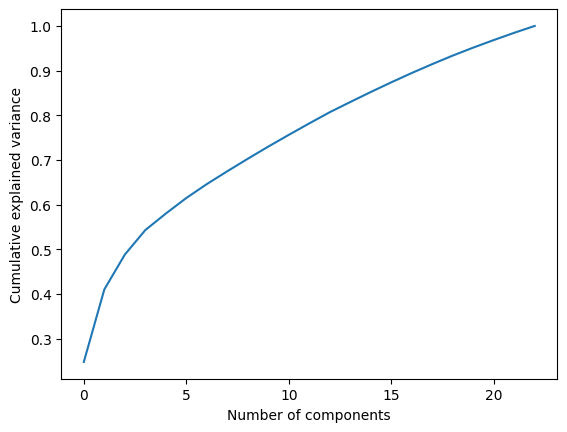

In [ ]:
pca = PCA()
pca.fit(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

## 4. Factor scoring and discretization for persona inputs
We compute respondent-level factor scores and then discretize each factor into tertiles (Low/Medium/High) via qcut to produce stable, interpretable categorical inputs for persona generation.

Note: tertiles impose equal marginal shares by design; the structural information is preserved in the conditional distributions (e.g., Party x Factor).

In [ ]:
fa = FactorAnalyzer(n_factors=3, rotation='oblimin')
fa.fit(X_scaled)

loadings = pd.DataFrame(fa.loadings_, index=df_att.columns)
loadings

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,0,1,2
Q19X_1,0.068020,0.585407,-0.039724
Q19X_2,-0.057200,0.563493,-0.028620
Q19X_3,0.039206,0.525461,0.037542
Q19X_4,-0.048033,0.574004,-0.051145
Q19X_5,-0.030873,0.583558,-0.043406
Q19X_6,-0.031852,0.708543,0.046196
Q19X_7,0.062656,0.623698,-0.033020
Q19X_8,0.092646,0.493978,0.073774
Q20X_1,0.781536,-0.010522,0.006297
Q20X_2,0.615757,-0.011747,0.036508


In [ ]:
loadings.abs().sort_values(by=0, ascending=False).head(10)

,0,1,2
Q20X_1,0.781536,0.010522,0.006297
Q20X_7,0.761998,0.006509,0.012931
Q20X_6,0.755262,0.000332,0.032839
Q20X_5,0.724422,0.039138,0.014335
Q20X_4,0.707787,0.007148,0.050798
Q20X_3,0.707247,0.023376,0.060864
Q20X_8,0.671191,0.056370,0.037050
Q20X_2,0.615757,0.011747,0.036508
Q22_4,0.155315,0.040753,0.536113
Q22_12,0.098953,0.114036,0.658427


In [ ]:
factor_scores = pd.DataFrame(
    fa.transform(X_scaled),
    columns=["F_performance", "F_importance", "F_belief"]
)

df_factors = pd.concat([df_clean.reset_index(drop=True), factor_scores], axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Factor 0 (Performance Perception)**

High score = Believes large companies are currently performing well

Low score = Believes large companies are currently performing poorly

**Factor 1 (Justice Importance Orientation)**

High score = Believes companies should have a high degree of social and labor responsibility

Low score = Lower expectations for these responsibilities

**Factor 2 (Corporate Trust / Structural Belief)**

High score = More trust in businesses as a social force

Low score = More skeptical of businesses

#Joint distributions

## 5. Selecting structural targets (joint constraints)
We quantify pairwise association using Cramér's V to prioritize a small set of high-signal joints.

We then export conditional distributions P(Y | X) (row-normalized crosstabs) as explicit statistical targets for synthetic persona generation.

In [ ]:
for col in ["F_performance", "F_importance", "F_belief"]:
    df_factors[col + "_level"] = pd.qcut(
        df_factors[col],
        q=3,
        labels=["1", "2", "3"]
    )

1 = Low = Respondent assigns relatively low importance to corporate social priorities

2 = Medium = Moderate importance orientation

3 = High = Strong importance orientation



In [ ]:
df_factors[["F_performance","F_importance","F_belief"]].corr()

,F_performance,F_importance,F_belief
F_performance,1.000000,-0.057895,0.468733
F_importance,-0.057895,1.000000,-0.456557
F_belief,0.468733,-0.456557,1.000000


In [ ]:
vars_demo = ["PAGEFINAL3","PRACE","PEDUCATION","PEMPLOY",
             "PPOLPARTY","PMETRO","PREGION","D10","D5","D11"]

vars_factor = ["F_importance_level",
               "F_performance_level",
               "F_belief_level"]

In [ ]:
def make_crosstab(df, var1, var2):
    tab = pd.crosstab(df[var1], df[var2], normalize="index")
    tab = tab.round(3)
    print(f"\n=== {var1} × {var2} ===")
    display(tab)
    return tab

###Demo x Demo

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

vars_demo = ["PAGEFINAL3","PRACE","PEDUCATION","PEMPLOY",
             "PPOLPARTY","PMETRO","PREGION","D10","D5","D11"]

def cramers_v(a, b):
    tab = pd.crosstab(a, b)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

pairs_demo = []

for i in range(len(vars_demo)):
    for j in range(i+1, len(vars_demo)):
        v1, v2 = vars_demo[i], vars_demo[j]
        val = cramers_v(df_factors[v1], df_factors[v2])
        pairs_demo.append((v1, v2, val))

demo_df = pd.DataFrame(pairs_demo, columns=["var1","var2","cramers_v"]) \
           .sort_values("cramers_v", ascending=False)

demo_df.head(10)

,var1,var2,cramers_v
2,PAGEFINAL3,PEMPLOY,0.338823
21,PEDUCATION,D10,0.315226
23,PEDUCATION,D11,0.275748
11,PRACE,PPOLPARTY,0.227318
44,D5,D11,0.223154
17,PEDUCATION,PEMPLOY,0.207743
13,PRACE,PREGION,0.198120
27,PEMPLOY,D10,0.195615
12,PRACE,PMETRO,0.175906
34,PPOLPARTY,D11,0.166406


In [ ]:
tab_age_emplo = make_crosstab(df_factors, "PAGEFINAL3", "PEMPLOY")
tab_edu_income = make_crosstab(df_factors, "PEDUCATION", "D10")
tab_edu_indus = make_crosstab(df_factors, "PEDUCATION", "D11")
tab_race_party = make_crosstab(df_factors, "PRACE", "PPOLPARTY")
tab_gander_indus = make_crosstab(df_factors, "D5", "D11")


=== PAGEFINAL3 × PEMPLOY ===


PEMPLOY,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
PAGEFINAL3,,,,,,,,
1.0,0.209,0.349,0.000,0.000,0.256,0.047,0.023,0.116
2.0,0.438,0.272,0.000,0.043,0.099,0.111,0.019,0.019
3.0,0.582,0.127,0.006,0.073,0.048,0.097,0.055,0.012
4.0,0.645,0.175,0.000,0.090,0.005,0.060,0.015,0.010
5.0,0.546,0.153,0.000,0.123,0.006,0.074,0.067,0.031
6.0,0.642,0.082,0.000,0.094,0.006,0.075,0.075,0.025
7.0,0.680,0.112,0.000,0.101,0.000,0.034,0.051,0.022
8.0,0.683,0.090,0.000,0.083,0.007,0.021,0.103,0.014
9.0,0.586,0.138,0.066,0.046,0.000,0.020,0.145,0.000



=== PEDUCATION × D10 ===


D10,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
PEDUCATION,,,,,,,,,,
1.0,0.344,0.151,0.109,0.141,0.073,0.099,0.010,0.026,0.016,0.031
2.0,0.102,0.116,0.089,0.122,0.102,0.180,0.122,0.102,0.019,0.046
3.0,0.063,0.068,0.066,0.110,0.088,0.202,0.159,0.188,0.027,0.029
4.0,0.012,0.020,0.025,0.033,0.053,0.137,0.187,0.387,0.087,0.059



=== PEDUCATION × D11 ===


D11,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0
PEDUCATION,,,,,,,,,,,,,,,,,,,
1.0,0.058,0.013,0.038,0.128,0.115,0.013,0.205,0.077,0.019,0.013,0.013,0.026,0.006,0.045,0.026,0.090,0.032,0.071,0.013
2.0,0.025,0.012,0.023,0.124,0.131,0.030,0.169,0.106,0.018,0.028,0.007,0.028,0.005,0.023,0.033,0.091,0.031,0.081,0.035
3.0,0.022,0.005,0.027,0.060,0.068,0.014,0.133,0.076,0.038,0.062,0.016,0.046,0.011,0.027,0.046,0.177,0.049,0.065,0.057
4.0,0.012,0.007,0.013,0.028,0.065,0.018,0.062,0.028,0.052,0.062,0.022,0.128,0.008,0.008,0.187,0.188,0.040,0.022,0.050



=== PRACE × PPOLPARTY ===


PPOLPARTY,1.0,2.0,3.0
PRACE,,,
1.0,0.434,0.244,0.322
2.0,0.075,0.575,0.349
3.0,0.291,0.387,0.322
4.0,0.235,0.647,0.118
5.0,0.154,0.444,0.402
6.0,0.220,0.396,0.385
7.0,0.571,0.143,0.286
8.0,0.000,0.000,1.000
9.0,1.000,0.000,0.000



=== D5 × D11 ===


D11,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0
D5,,,,,,,,,,,,,,,,,,,
1.0,0.026,0.016,0.024,0.128,0.121,0.024,0.098,0.096,0.046,0.044,0.010,0.077,0.009,0.021,0.056,0.070,0.035,0.049,0.050
2.0,0.020,0.002,0.021,0.030,0.066,0.016,0.158,0.045,0.024,0.047,0.018,0.057,0.006,0.021,0.119,0.213,0.037,0.062,0.037
3.0,0.000,0.000,0.000,0.000,0.000,0.077,0.077,0.077,0.000,0.000,0.000,0.000,0.000,0.000,0.231,0.231,0.308,0.000,0.000
7.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.250,0.000,0.000,0.000,0.250,0.000,0.500,0.000


###Demo x Factor

In [ ]:
vars_factor = ["F_importance_level",
               "F_performance_level",
               "F_belief_level"]

pairs_df = []

for v1 in vars_demo:
    for v2 in vars_factor:
        val = cramers_v(df_factors[v1], df_factors[v2])
        pairs_df.append((v1, v2, val))

demo_factor_df = pd.DataFrame(pairs_df,
                              columns=["demo","factor","cramers_v"]) \
                  .sort_values("cramers_v", ascending=False)

demo_factor_df.head(10)

,demo,factor,cramers_v
14,PPOLPARTY,F_belief_level,0.210138
13,PPOLPARTY,F_performance_level,0.209006
12,PPOLPARTY,F_importance_level,0.166974
28,D11,F_performance_level,0.153585
29,D11,F_belief_level,0.149061
3,PRACE,F_importance_level,0.141648
8,PEDUCATION,F_belief_level,0.137022
27,D11,F_importance_level,0.130592
1,PAGEFINAL3,F_performance_level,0.128537
21,D10,F_importance_level,0.128141


In [ ]:
tab_party_belief = make_crosstab(df_factors, "PPOLPARTY", "F_belief_level")
tab_party_perf = make_crosstab(df_factors, "PPOLPARTY", "F_performance_level")
tab_party_import = make_crosstab(df_factors, "PPOLPARTY", "F_importance_level")
tab_indus_perf = make_crosstab(df_factors, "D11", "F_performance_level")
tab_indus_belief = make_crosstab(df_factors, "D11", "F_belief_level")
tab_race_import = make_crosstab(df_factors, "PRACE", "F_importance_level")


=== PPOLPARTY × F_belief_level ===


F_belief_level,1,2,3
PPOLPARTY,,,
1.0,0.433,0.385,0.182
2.0,0.197,0.287,0.516
3.0,0.336,0.340,0.324



=== PPOLPARTY × F_performance_level ===


F_performance_level,1,2,3
PPOLPARTY,,,
1.0,0.474,0.376,0.150
2.0,0.230,0.303,0.467
3.0,0.302,0.331,0.367



=== PPOLPARTY × F_importance_level ===


...

F_performance_level,1,2,3
D11,,,
1.0,0.359,0.333,0.308
2.0,0.438,0.375,0.188
3.0,0.333,0.231,0.436
4.0,0.419,0.404,0.176
5.0,0.379,0.385,0.236
6.0,0.444,0.389,0.167
7.0,0.338,0.333,0.329
8.0,0.301,0.325,0.374
9.0,0.361,0.230,0.410



=== D11 × F_belief_level ===


F_belief_level,1,2,3
D11,,,
1.0,0.385,0.333,0.282
2.0,0.500,0.250,0.250
3.0,0.487,0.282,0.231
4.0,0.485,0.331,0.184
5.0,0.373,0.373,0.255
6.0,0.361,0.361,0.278
7.0,0.324,0.324,0.351
8.0,0.252,0.439,0.309
9.0,0.311,0.328,0.361



=== PRACE × F_importance_level ===


F_importance_level,1,2,3
PRACE,,,
1.0,0.282,0.364,0.354
2.0,0.510,0.277,0.213
3.0,0.377,0.302,0.321
4.0,0.474,0.000,0.526
5.0,0.336,0.295,0.370
6.0,0.248,0.371,0.381
7.0,0.667,0.000,0.333
8.0,0.500,0.500,0.000
9.0,0.333,0.667,0.000


###Together

In [ ]:
tabs = {
    'age_emplo': tab_age_emplo,
    "edu_income": tab_edu_income,
    "edu_indus": tab_edu_indus,
    "race_party": tab_race_party,
    "gander_indus": tab_gander_indus,
    "party_belief": tab_party_belief,
    "party_perf": tab_party_perf,
    "party_import": tab_party_import,
    "indus_perf": tab_indus_perf,
    "indus_belief": tab_indus_belief,
    "race_import": tab_race_import
}

for name, table in tabs.items():
    table.to_csv(f"{name}_target.csv")

## 6. Additional coherence constraints (Factor x Factor)
We generate 2,005 synthetic personas to match the observed structural constraints.

Generation proceeds in two stages:

1. Sample demographic backbone according to observed joint distributions.
2. Sample factor levels conditionally (e.g., Party x Factor targets).
3. Preserve factor-factor correlation structure.

In [ ]:
tab_belief_perf = make_crosstab(df_factors, "F_belief_level", "F_performance_level")
tab_belief_import = make_crosstab(df_factors, "F_belief_level", "F_importance_level")

tab_belief_perf.to_csv("belief_perf_target.csv")
tab_belief_import.to_csv("belief_import_target.csv")


=== F_belief_level × F_performance_level ===


F_performance_level,1,2,3
F_belief_level,,,
1,0.591,0.298,0.111
2,0.274,0.425,0.301
3,0.135,0.277,0.588



=== F_belief_level × F_importance_level ===


F_importance_level,1,2,3
F_belief_level,,,
1,0.154,0.268,0.578
2,0.266,0.413,0.320
3,0.579,0.319,0.102


Given substantial inter-factor correlation (|r| ≈ 0.45-0.47),
we preserve factor co-structure when generating synthetic personas.

## 7. Persona seed table for LLM generation
We create a structured seed table (N=2005) containing demographics + factor levels to serve as inputs for LLM persona generation.

In [ ]:
persona_seed_cols = [
    "PAGEFINAL3","D5","PRACE","PEDUCATION","D10",
    "PPOLPARTY","PMETRO","PREGION","D11","PEMPLOY",
    "F_importance_level","F_performance_level","F_belief_level"
]
persona_seeds = df_factors[persona_seed_cols].copy()

persona_seeds = persona_seeds.sample(n=2005, replace=True, random_state=42).reset_index(drop=True)
persona_seeds.insert(0, "persona_id", range(1, len(persona_seeds)+1))

persona_seeds.to_csv("Persona_Seeds.csv", index=False)